# 06. Overlap and Trimming

In the previous notebook, we treated balance diagnostics as a design gate. This notebook studies another design gate that is just as important: **overlap**.

Overlap asks whether the observed data contain comparable treated and untreated units for the covariate profiles where we want to make causal claims. In industry work, overlap problems are common because teams do not assign treatments randomly. They target retention campaigns to high-risk accounts, premium support to strategic customers, discounts to price-sensitive prospects, and fraud interventions to suspicious transactions. That targeting is often the business logic we want to learn from, but it also creates regions where one treatment condition is barely observed.

The core theme of this lecture is simple:

> If the data do not contain both treated and untreated units in a region of the covariate space, no adjustment method can manufacture a credible comparison there.

Trimming, overlap weighting, ATT targeting, and related approaches are not just technical fixes. They usually change the target population. A professional causal analysis should say that out loud.

## Learning Goals

By the end of this notebook, you should be able to:

1. Define positivity, common support, and practical overlap in propensity-score language.
2. Diagnose overlap problems using propensity-score distributions, score-bin support tables, and weight diagnostics.
3. Explain why extreme inverse probability weights are often a symptom of weak overlap.
4. Compare the full-population ATE, trimmed ATE, ATT, and overlap-weighted target estimands.
5. Show, with code, that trimming can improve stability while changing the population being described.
6. Write an industry-facing overlap report that is honest about where the data support causal claims.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.special import expit
from sklearn.metrics import roc_auc_score
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 3)

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Create a Graphviz DAG with consistent lecture styling."""
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="DejaVu Sans",
        fontsize="11",
        margin="0.12,0.08",
        color="#334155",
    )
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def clip_prob(p, eps=1e-4):
    return np.clip(np.asarray(p, dtype=float), eps, 1 - eps)


def weighted_mean_and_var(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mean = np.sum(w * x) / np.sum(w)
    var = np.sum(w * (x - mean) ** 2) / np.sum(w)
    return mean, var


def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return np.sum(w * x) / np.sum(w)


def weighted_difference(frame, outcome="outcome", treatment="treated", weights=None):
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    y = frame[outcome].to_numpy(dtype=float)
    return weighted_mean(y[treated], weights[treated]) - weighted_mean(y[~treated], weights[~treated])


def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=float)
    return (weights.sum() ** 2) / np.sum(weights ** 2)


def standardized_mean_differences(frame, covariates, treatment="treated", weights=None):
    """Compute standardized mean differences, optionally with design weights."""
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    rows = []
    for col in covariates:
        x = frame[col].to_numpy(dtype=float)
        mt, vt = weighted_mean_and_var(x[treated], weights[treated])
        mc, vc = weighted_mean_and_var(x[~treated], weights[~treated])
        pooled_sd = np.sqrt((vt + vc) / 2)
        smd = np.nan if pooled_sd == 0 else (mt - mc) / pooled_sd
        rows.append({
            "covariate": col,
            "treated_mean": mt,
            "control_mean": mc,
            "smd": smd,
            "abs_smd": abs(smd),
        })
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def balance_dashboard(balance_table, weights=None, threshold=0.10):
    row = {
        "max_abs_smd": balance_table["abs_smd"].max(),
        "mean_abs_smd": balance_table["abs_smd"].mean(),
        "covariates_above_0.10": int((balance_table["abs_smd"] > threshold).sum()),
    }
    if weights is not None:
        row["ess"] = effective_sample_size(weights)
        row["ess_share_of_n"] = row["ess"] / len(weights)
        row["max_weight"] = np.max(weights)
        row["p99_weight"] = np.quantile(weights, 0.99)
    return row


def plot_love(balance_tables, title, threshold=0.10, figsize=None):
    plot_df = pd.concat(
        [table.assign(design=label) for label, table in balance_tables.items()],
        ignore_index=True,
    )
    order = plot_df.groupby("covariate")["abs_smd"].max().sort_values(ascending=True).index
    if figsize is None:
        figsize = (9, max(4.5, 0.38 * len(order)))
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=plot_df,
        x="smd",
        y="covariate",
        hue="design",
        style="design",
        s=80,
        ax=ax,
        zorder=3,
    )
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.axvline(threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.axvline(-threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("Standardized mean difference")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
    plt.show()


def ate_weights(treated, ps):
    treated = np.asarray(treated, dtype=int)
    ps = clip_prob(ps)
    return treated / ps + (1 - treated) / (1 - ps)


def att_weights(treated, ps):
    treated = np.asarray(treated, dtype=int)
    ps = clip_prob(ps)
    return treated + (1 - treated) * ps / (1 - ps)


def overlap_weights(treated, ps):
    treated = np.asarray(treated, dtype=int)
    ps = clip_prob(ps)
    return treated * (1 - ps) + (1 - treated) * ps


def weight_summary(weights):
    weights = np.asarray(weights, dtype=float)
    return {
        "ess": effective_sample_size(weights),
        "ess_share_of_n": effective_sample_size(weights) / len(weights),
        "mean": weights.mean(),
        "sd": weights.std(),
        "p95": np.quantile(weights, 0.95),
        "p99": np.quantile(weights, 0.99),
        "max": weights.max(),
    }

## 1. Why Overlap Is a Design Assumption

Consider a customer-success team evaluating whether a high-touch outreach program improves renewal value. The program is not assigned randomly. Account managers prioritize enterprise accounts, customers with high churn risk, and accounts with large contracts.

Those assignment rules create a design problem. Some customer profiles are almost always contacted. Other profiles are almost never contacted. If we try to estimate the effect for everyone, we may be asking the model to compare treated enterprise-risk accounts to control accounts that do not actually look like them.

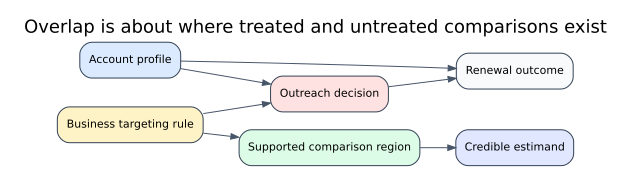

In [3]:
overlap_edges = [
    ("Account profile", "Outreach decision"),
    ("Account profile", "Renewal outcome"),
    ("Business targeting rule", "Outreach decision"),
    ("Business targeting rule", "Supported comparison region"),
    ("Outreach decision", "Renewal outcome"),
    ("Supported comparison region", "Credible estimand"),
]

make_dag(
    overlap_edges,
    title="Overlap is about where treated and untreated comparisons exist",
    node_colors={
        "Account profile": "#dbeafe",
        "Business targeting rule": "#fef3c7",
        "Supported comparison region": "#dcfce7",
        "Credible estimand": "#e0e7ff",
        "Outreach decision": "#fee2e2",
        "Renewal outcome": "#f8fafc",
    },
)

### Interpretation

The graph separates two ideas that are often blurred together:

1. **Confounding**: account profile affects both outreach and renewal outcome.
2. **Overlap**: for some account profiles, one of the treatment conditions may be rare or absent.

Adjustment methods address confounding only in regions where comparison data exist. If the organization never withholds outreach from a certain type of account, then the untreated potential outcome for that type is not represented by observed untreated accounts. A model can extrapolate, but that extrapolation is no longer primarily a design-based comparison.

## 2. Positivity, Common Support, and Practical Overlap

Let $D_i$ be the treatment indicator and $X_i$ be the covariates we adjust for. The propensity score is:

$$
e(X_i) = P(D_i = 1 \mid X_i).
$$

For the full-population ATE to be identified from observational data under ignorability, we need positivity:

$$
0 < P(D_i = 1 \mid X_i = x) < 1
$$

for every covariate profile $x$ in the target population. A stronger finite-sample version says the probability should be bounded away from zero and one:

$$
\epsilon < e(X_i) < 1 - \epsilon
$$

for some meaningful $\epsilon > 0$.

Westreich and Cole (2010) discuss positivity as the requirement that, within the covariate patterns used for adjustment, both exposed and unexposed participants are possible. Petersen et al. (2010) emphasize that violations can be structural, where treatment is impossible by design, or practical, where a treatment level is theoretically possible but sparsely observed.

In industry language:

- **Structural positivity problem**: the business rule forbids one action for some customer type. Example: free-tier customers are never assigned a dedicated enterprise success manager.
- **Practical overlap problem**: both actions are possible, but historical data contain very few examples of one action. Example: almost every large, high-risk enterprise account receives high-touch outreach.

## 3. Running Example: Targeted Renewal Outreach

We will simulate a SaaS renewal setting. The company wants to estimate the effect of proactive outreach on a renewal-value outcome.

The historical targeting rule is intentionally aggressive:

- high churn-risk accounts are much more likely to receive outreach;
- enterprise and mid-market accounts are more likely to receive outreach;
- large contracts receive extra attention;
- low-usage accounts receive more attention;
- a strict business rule pushes very large, high-risk enterprise accounts toward treatment.

The treatment effect is heterogeneous. Outreach is more useful for larger and enterprise accounts, but less useful for accounts with very high churn risk, where some problems may be too severe for outreach alone to solve.

In [4]:
def simulate_overlap_problem(n=9000, seed=6060):
    rng = np.random.default_rng(seed)

    segment = rng.choice(["self_serve", "mid_market", "enterprise"], p=[0.46, 0.34, 0.20], size=n)
    segment_score = pd.Series(segment).map({"self_serve": 0.0, "mid_market": 0.5, "enterprise": 1.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.0, scale=8.0, size=n), 1, 60)
    seats = np.clip(np.exp(rng.normal(2.4 + 0.55 * segment_score, 0.75, n)), 2, 160)
    usage = np.clip(rng.normal(42 + 0.33 * tenure + 8 * segment_score + 0.15 * seats, 13, n), 2, 140)
    contract_value = np.clip(
        rng.lognormal(3.6 + 0.32 * segment_score + 0.005 * seats, 0.55, n),
        15,
        800,
    )

    health_score = expit(
        -0.7
        + 0.045 * usage
        + 0.004 * contract_value
        - 0.015 * tenure
        + rng.normal(0, 0.7, n)
    )
    churn_risk = expit(
        1.8
        - 0.070 * usage
        - 0.006 * contract_value
        + 0.018 * tenure
        - 1.20 * (segment == "enterprise")
        + rng.normal(0, 0.9, n)
    )

    strict_rule = ((segment == "enterprise") & (contract_value > 250) & (churn_risk > 0.35)).astype(float)

    true_propensity = expit(
        -3.7
        + 7.8 * churn_risk
        + 1.8 * (segment == "enterprise")
        + 0.85 * (segment == "mid_market")
        + 0.010 * contract_value
        - 0.035 * usage
        + 2.2 * strict_rule
    )
    treated = rng.binomial(1, true_propensity)

    y0 = (
        48
        + 0.10 * usage
        + 0.025 * contract_value
        + 0.08 * tenure
        + 4.0 * segment_score
        + 9.0 * health_score
        - 17.0 * churn_risk
        + rng.normal(0, 4.8, n)
    )

    treatment_effect = (
        2.2
        + 1.25 * (segment == "enterprise")
        + 0.55 * (segment == "mid_market")
        + 0.010 * usage
        - 1.80 * churn_risk
        + 0.0015 * contract_value
    )
    outcome = y0 + treatment_effect * treated

    return pd.DataFrame({
        "segment": segment,
        "tenure": tenure,
        "seats": seats,
        "usage": usage,
        "contract_value": contract_value,
        "health_score": health_score,
        "churn_risk": churn_risk,
        "strict_targeting_rule": strict_rule,
        "true_propensity": true_propensity,
        "treated": treated,
        "outcome": outcome,
        "outcome_without_treatment": y0,
        "true_individual_effect": treatment_effect,
    })


df = simulate_overlap_problem()
true_ate = df["true_individual_effect"].mean()
naive_effect = weighted_difference(df)

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "True full-population ATE",
        "Naive treated-control difference",
        "Naive bias vs full ATE",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        true_ate,
        naive_effect,
        naive_effect - true_ate,
    ],
})

display(summary)
display(df.head())

,quantity,value
0,Number of accounts,9000.000
1,Share receiving outreach,0.102
2,True full-population ATE,2.943
3,Naive treated-control difference,-5.105
4,Naive bias vs full ATE,-8.048


,segment,tenure,seats,usage,contract_value,health_score,churn_risk,strict_targeting_rule,true_propensity,treated,outcome,outcome_without_treatment,true_individual_effect
0,mid_market,9.881,25.496,54.131,30.685,0.957,0.070,0.0,0.020,0,59.326,59.326,3.211
1,self_serve,10.348,4.721,53.927,20.495,0.815,0.120,0.0,0.012,0,56.195,56.195,2.554
2,self_serve,1.858,13.923,50.856,25.106,0.909,0.053,0.0,0.008,0,57.788,57.788,2.651
3,enterprise,9.483,32.792,56.431,162.853,0.949,0.028,0.0,0.116,0,73.764,73.764,4.208
4,mid_market,10.821,13.193,28.404,26.140,0.774,0.466,0.0,0.512,0,45.314,45.314,2.235


### Interpretation

The naive treated-control comparison is not just wrong; it has the wrong sign in this simulation. That is not because outreach harms accounts. It is because outreach is targeted toward accounts that were already at higher risk.

This is exactly the kind of setting where observational causal inference can be valuable. But before fitting estimators, we have to ask whether the targeted assignment rule left enough untreated examples among high-priority accounts and enough treated examples among lower-priority accounts.

## 4. Estimate the Propensity Score

In a real project, the true assignment probability is unknown. We estimate it from observed covariates. Here we fit a logistic propensity model using variables that would plausibly be logged before the outreach decision.

The model is not the estimand. It is a diagnostic device and a design tool. If the fitted scores reveal that large regions have scores near zero or one, the analysis has a support problem even before we look at outcomes.

In [5]:
ps_model = smf.glm(
    "treated ~ churn_risk + health_score + usage + contract_value + tenure + seats + strict_targeting_rule + C(segment)",
    data=df,
    family=sm.families.Binomial(),
).fit(maxiter=100)

df["ps_hat"] = clip_prob(ps_model.predict(df))
df["ate_weight"] = ate_weights(df["treated"], df["ps_hat"])
df["att_weight"] = att_weights(df["treated"], df["ps_hat"])
df["overlap_weight"] = overlap_weights(df["treated"], df["ps_hat"])

auc = roc_auc_score(df["treated"], df["ps_hat"])
ps_summary = pd.DataFrame({
    "quantity": [
        "Propensity model AUC",
        "Minimum estimated propensity",
        "1st percentile estimated propensity",
        "Median estimated propensity",
        "99th percentile estimated propensity",
        "Maximum estimated propensity",
    ],
    "value": [
        auc,
        df["ps_hat"].min(),
        df["ps_hat"].quantile(0.01),
        df["ps_hat"].median(),
        df["ps_hat"].quantile(0.99),
        df["ps_hat"].max(),
    ],
})

display(ps_summary)
display(ps_model.summary2().tables[1].round(3))

,quantity,value
0,Propensity model AUC,0.866
1,Minimum estimated propensity,0.001
2,1st percentile estimated propensity,0.003
3,Median estimated propensity,0.036
4,99th percentile estimated propensity,0.846
5,Maximum estimated propensity,0.980


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-2.220,0.306,-7.264,0.000,-2.819,-1.621
C(segment)[T.mid_market],-0.960,0.128,-7.488,0.000,-1.211,-0.708
C(segment)[T.self_serve],-1.832,0.141,-12.997,0.000,-2.108,-1.556
churn_risk,7.694,0.298,25.861,0.000,7.111,8.277
health_score,0.329,0.346,0.950,0.342,-0.350,1.008
usage,-0.031,0.005,-6.365,0.000,-0.041,-0.021
contract_value,0.010,0.001,8.499,0.000,0.008,0.012
tenure,-0.007,0.004,-1.666,0.096,-0.016,0.001
seats,0.000,0.003,0.162,0.871,-0.005,0.006
strict_targeting_rule,0.000,0.000,NaN,NaN,0.000,0.000


### Interpretation

A high propensity-model AUC is not automatically good news. For prediction, high AUC means the model separates treated from untreated accounts well. For causal adjustment, strong separation can be a warning sign: the historical process made treatment almost deterministic for some accounts.

When propensity scores are near zero, treated observations in that region receive very large ATE weights. When propensity scores are near one, control observations in that region receive very large ATE weights. Those large weights are the estimator's attempt to reconstruct a comparison that the data barely contain.

## 5. Visualize Propensity-Score Overlap

The fastest first diagnostic is a distribution plot of the estimated propensity score by treatment group. We want substantial overlap, not just two distributions that touch at the edges.

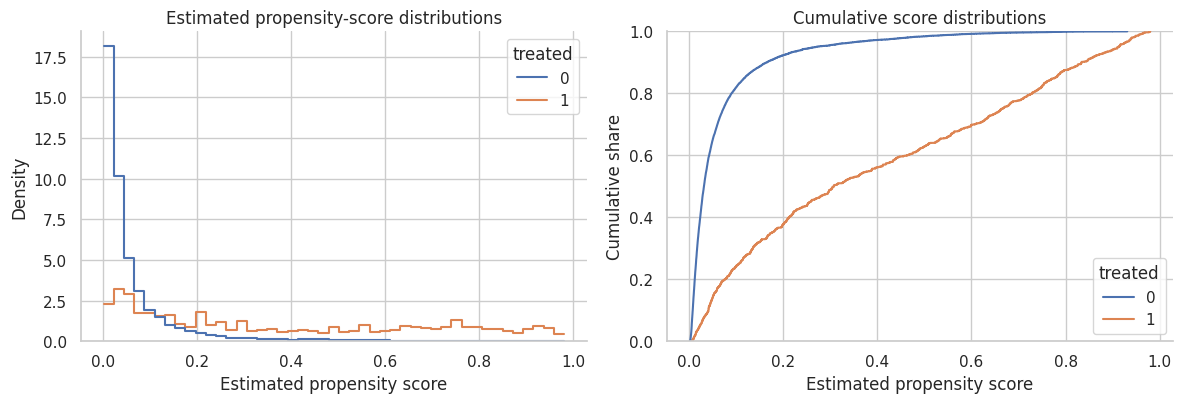

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(
    data=df,
    x="ps_hat",
    hue="treated",
    stat="density",
    common_norm=False,
    bins=45,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Estimated propensity-score distributions")
axes[0].set_xlabel("Estimated propensity score")

sns.ecdfplot(
    data=df,
    x="ps_hat",
    hue="treated",
    ax=axes[1],
)
axes[1].set_title("Cumulative score distributions")
axes[1].set_xlabel("Estimated propensity score")
axes[1].set_ylabel("Cumulative share")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

The untreated group has a large mass at low estimated treatment probabilities. The treated group is shifted heavily toward higher scores. The two groups overlap, but the overlap is not evenly distributed.

This has a practical interpretation: many low-risk or lower-value accounts were almost never contacted, and many high-priority accounts were usually contacted. A full-population ATE asks us to learn what outreach would do for all accounts, including account profiles where the historical data contain thin comparisons.

## 6. Common-Support Tables

Plots are useful, but decision reviews need tables. We can summarize overlap by treatment group, then count treated and untreated units inside score bins.

In [7]:
score_support = (
    df.groupby("treated")["ps_hat"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])
    .rename(index={0: "No outreach", 1: "Outreach"})
)

treated_scores = df.loc[df["treated"] == 1, "ps_hat"]
control_scores = df.loc[df["treated"] == 0, "ps_hat"]
common_lower = max(treated_scores.min(), control_scores.min())
common_upper = min(treated_scores.max(), control_scores.max())
inside_common_support = df["ps_hat"].between(common_lower, common_upper)

support_summary = pd.DataFrame({
    "quantity": [
        "Lower edge of empirical common support",
        "Upper edge of empirical common support",
        "Share of all accounts inside empirical common support",
        "Share of outreach accounts inside empirical common support",
        "Share of no-outreach accounts inside empirical common support",
    ],
    "value": [
        common_lower,
        common_upper,
        inside_common_support.mean(),
        inside_common_support[df["treated"] == 1].mean(),
        inside_common_support[df["treated"] == 0].mean(),
    ],
})

display(score_support)
display(support_summary)

,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
treated,,,,,,,,,,,,
No outreach,8086.0,0.069,0.107,0.001,0.003,0.006,0.008,0.032,0.166,0.270,0.573,0.931
Outreach,914.0,0.389,0.303,0.005,0.010,0.023,0.041,0.308,0.834,0.912,0.957,0.980


,quantity,value
0,Lower edge of empirical common support,0.005
1,Upper edge of empirical common support,0.931
2,Share of all accounts inside empirical common ...,0.954
3,Share of outreach accounts inside empirical co...,0.967
4,Share of no-outreach accounts inside empirical...,0.952


In [8]:
score_bins = pd.IntervalIndex.from_breaks([0, 0.01, 0.03, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00], closed="left")
score_bin_frame = df.copy()
score_bin_frame["score_bin"] = pd.cut(score_bin_frame["ps_hat"], bins=score_bins)

bin_support = (
    score_bin_frame
    .groupby("score_bin", observed=True)
    .agg(
        accounts=("treated", "size"),
        outreach=("treated", "sum"),
        no_outreach=("treated", lambda x: (1 - x).sum()),
        outreach_share=("treated", "mean"),
        mean_contract_value=("contract_value", "mean"),
        mean_churn_risk=("churn_risk", "mean"),
    )
    .reset_index()
)
bin_support["min_group_count"] = bin_support[["outreach", "no_outreach"]].min(axis=1)
bin_support["support_flag"] = np.where(bin_support["min_group_count"] >= 30, "usable", "thin")

display(bin_support)

,score_bin,accounts,outreach,no_outreach,outreach_share,mean_contract_value,mean_churn_risk,min_group_count,support_flag
0,"[0.0, 0.01)",1255,11,1244,0.009,39.388,0.047,11,thin
1,"[0.01, 0.03)",2712,55,2657,0.020,49.912,0.082,55,usable
2,"[0.03, 0.05)",1408,62,1346,0.044,57.135,0.112,62,usable
3,"[0.05, 0.1)",1474,93,1381,0.063,60.842,0.165,93,usable
4,"[0.1, 0.2)",958,123,835,0.128,62.892,0.256,123,usable
5,"[0.2, 0.4)",566,169,397,0.299,57.858,0.385,169,usable
6,"[0.4, 0.6)",283,124,159,0.438,51.881,0.515,124,usable
7,"[0.6, 0.8)",219,163,56,0.744,50.643,0.626,56,usable
8,"[0.8, 1.0)",125,114,11,0.912,57.952,0.766,11,thin


### Interpretation

The empirical common-support interval can look deceptively comforting because almost everyone may fall between the smallest treated score and the largest control score. But common support in the strict min-max sense is weak. The more relevant question is local: within a score region, do we have enough observations from both groups to make a stable comparison?

The score-bin table is more operational. Bins with very few treated accounts or very few control accounts are places where estimates will lean heavily on modeling choices or large weights.

## 7. Extreme Weights as an Overlap Diagnostic

ATE inverse probability weights are:

$$
w_i^{ATE} = \frac{D_i}{\hat e(X_i)} + \frac{1 - D_i}{1 - \hat e(X_i)}.
$$

These weights create a pseudo-population representing the full target population. But when scores are close to zero or one, the denominator becomes small. Extreme weights are therefore not just a numerical inconvenience. They are a signal that the requested target population is poorly supported by the observed design.

Petersen et al. (2010) discuss weight truncation as a practical response to positivity problems, but emphasize the bias-variance tradeoff. Truncation can reduce variance by limiting extreme weights, but it can also change or distort the estimand if used casually.

,design,ess,ess_share_of_n,mean,sd,p95,p99,max
0,ATE IPW,760.026,0.084,2.034,6.697,3.629,24.355,182.798
1,ATT weights,1595.149,0.177,0.197,0.424,1.000,1.273,13.512
2,Overlap weights,2244.526,0.249,0.124,0.215,0.724,0.959,0.995


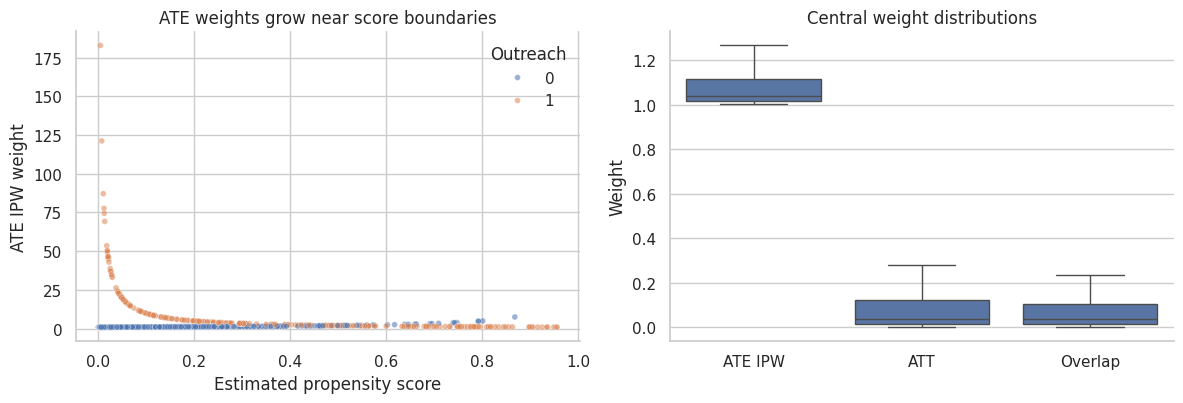

In [9]:
weight_diagnostics = pd.DataFrame([
    {"design": "ATE IPW", **weight_summary(df["ate_weight"])},
    {"design": "ATT weights", **weight_summary(df["att_weight"])},
    {"design": "Overlap weights", **weight_summary(df["overlap_weight"])},
])

display(weight_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.scatterplot(
    data=df.sample(2500, random_state=6),
    x="ps_hat",
    y="ate_weight",
    hue="treated",
    alpha=0.55,
    s=18,
    ax=axes[0],
)
axes[0].set_title("ATE weights grow near score boundaries")
axes[0].set_xlabel("Estimated propensity score")
axes[0].set_ylabel("ATE IPW weight")
axes[0].legend(title="Outreach", frameon=False)

plot_weight_df = df[["ate_weight", "att_weight", "overlap_weight"]].melt(
    var_name="weight_type",
    value_name="weight",
)
sns.boxplot(
    data=plot_weight_df,
    x="weight_type",
    y="weight",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Central weight distributions")
axes[1].set_xlabel("")
axes[1].set_ylabel("Weight")
axes[1].set_xticklabels(["ATE IPW", "ATT", "Overlap"])

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

The ATE weights are much more variable than the ATT or overlap weights. That is expected here. The ATE tries to represent everyone, including low-score accounts that were rarely treated and high-score accounts that were rarely untreated.

The effective sample size is especially useful. It answers: after weighting, how many equally weighted observations would carry about the same information? A design can have thousands of rows but only a small effective sample if a few observations dominate the weighted analysis.

## 8. Build a Balance Frame

Before comparing estimands, we need a consistent balance frame. This includes the continuous confounders and segment indicators.

,design,max_abs_smd,mean_abs_smd,covariates_above_0.10,ess,ess_share_of_n,max_weight,p99_weight
0,Raw groups,1.375e+00,4.192e-01,7,NaN,NaN,NaN,NaN
1,ATE IPW,8.389e-02,2.396e-02,0,760.026,0.084,182.798,24.355
2,ATT weights,9.653e-02,4.837e-02,0,1595.149,0.177,13.512,1.273
3,Overlap weights,1.390e-14,4.249e-15,0,2244.526,0.249,0.995,0.959


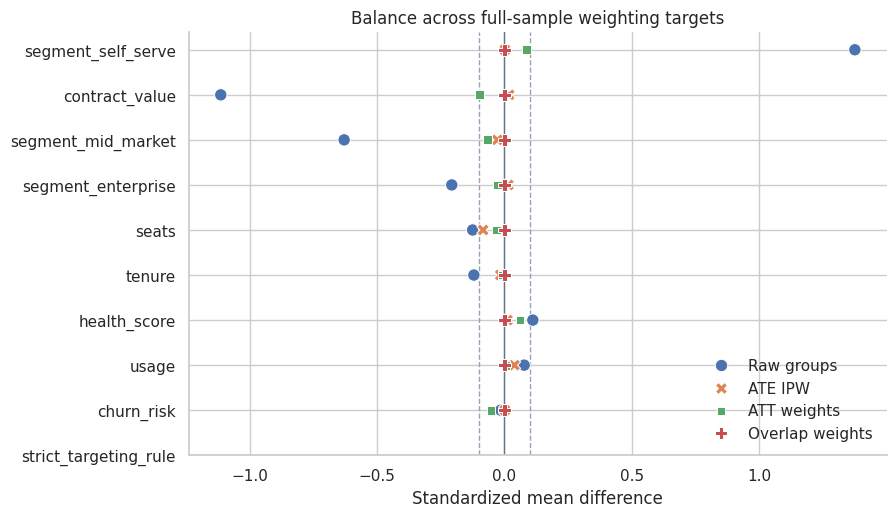

In [10]:
segment_dummies = pd.get_dummies(df["segment"], prefix="segment", dtype=float)
balance_frame = pd.concat(
    [
        df[[
            "treated",
            "churn_risk",
            "health_score",
            "usage",
            "contract_value",
            "tenure",
            "seats",
            "strict_targeting_rule",
        ]],
        segment_dummies,
    ],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]

balance_tables = {
    "Raw groups": standardized_mean_differences(balance_frame, balance_covariates),
    "ATE IPW": standardized_mean_differences(balance_frame, balance_covariates, weights=df["ate_weight"]),
    "ATT weights": standardized_mean_differences(balance_frame, balance_covariates, weights=df["att_weight"]),
    "Overlap weights": standardized_mean_differences(balance_frame, balance_covariates, weights=df["overlap_weight"]),
}

dashboard = pd.DataFrame([
    {"design": label, **balance_dashboard(table, None if label == "Raw groups" else df[{"ATE IPW": "ate_weight", "ATT weights": "att_weight", "Overlap weights": "overlap_weight"}[label]])}
    for label, table in balance_tables.items()
])

display(dashboard)
plot_love(balance_tables, title="Balance across full-sample weighting targets", figsize=(9, 5.5))

### Interpretation

Balance and overlap diagnostics should be read together.

A design may balance covariates well but still have extreme weights. That means the estimate depends on a small amount of information. A design may have stable weights but target a different population. Overlap weights often look attractive because they downweight the boundary regions, but that attractiveness comes from changing the target toward accounts where either outreach decision was plausible.

## 9. Estimands Before Estimators

The most important habit in this notebook is to separate the **estimand** from the **estimator**.

For a binary treatment, several common targets are:

$$
ATE = E[Y(1) - Y(0)]
$$

$$
ATT = E[Y(1) - Y(0) \mid D = 1]
$$

A trimmed ATE restricts the target to units whose estimated propensity scores lie inside a chosen interval:

$$
ATE_{\alpha} = E[Y(1) - Y(0) \mid \alpha \le \hat e(X) \le 1 - \alpha]
$$

Overlap weights target a population with density proportional to:

$$
h(X) = e(X)\{1 - e(X)\}.
$$

For treated units the overlap weight is $1 - \hat e(X_i)$, and for untreated units it is $\hat e(X_i)$. Li, Morgan, and Zaslavsky (2017) show that these weights emphasize units near propensity $1/2$ and are bounded, which makes them less sensitive to extreme weights than ordinary IPW.

In [11]:
def true_weighted_effect(frame, target_weights=None):
    if target_weights is None:
        target_weights = np.ones(len(frame))
    return weighted_mean(frame["true_individual_effect"], target_weights)


target_comparison = pd.DataFrame([
    {
        "target": "Full population ATE",
        "estimate": weighted_difference(df, weights=df["ate_weight"]),
        "true_target_effect": true_weighted_effect(df),
        "effective_sample_size": effective_sample_size(df["ate_weight"]),
        "max_weight": df["ate_weight"].max(),
    },
    {
        "target": "ATT among outreach accounts",
        "estimate": weighted_difference(df, weights=df["att_weight"]),
        "true_target_effect": true_weighted_effect(df, target_weights=df["treated"]),
        "effective_sample_size": effective_sample_size(df["att_weight"]),
        "max_weight": df["att_weight"].max(),
    },
    {
        "target": "Overlap population",
        "estimate": weighted_difference(df, weights=df["overlap_weight"]),
        "true_target_effect": true_weighted_effect(df, target_weights=df["ps_hat"] * (1 - df["ps_hat"])),
        "effective_sample_size": effective_sample_size(df["overlap_weight"]),
        "max_weight": df["overlap_weight"].max(),
    },
])
target_comparison["estimation_error_vs_target"] = target_comparison["estimate"] - target_comparison["true_target_effect"]

display(target_comparison)

,target,estimate,true_target_effect,effective_sample_size,max_weight,estimation_error_vs_target
0,Full population ATE,2.044,2.943,760.026,182.798,-0.899
1,ATT among outreach accounts,1.696,2.341,1595.149,13.512,-0.645
2,Overlap population,2.304,2.631,2244.526,0.995,-0.327


### Interpretation

The estimates are not answering the same question. The ATT emphasizes accounts that actually received outreach. The overlap target emphasizes accounts where the historical process was closer to equipoise. The full-population ATE asks about all accounts, including low-score accounts that rarely received outreach.

In this simulation, we can compute the true target effect because we generated both potential outcomes. In real projects, we cannot. But the simulation teaches the discipline: when we change weights or trim rows, we should update the sentence that describes the causal question.

## 10. Trimming by Propensity Score

A common response to weak overlap is to drop observations whose estimated propensity scores are too close to zero or one. Crump et al. (2009) formalized this idea as a way to improve precision under limited overlap by changing the target population.

For a simple symmetric trimming rule, keep accounts satisfying:

$$
\alpha \le \hat e(X_i) \le 1 - \alpha.
$$

The choice of $\alpha$ is a design choice. It should be justified by diagnostics and domain context, not chosen after checking which estimate is most convenient.

In [12]:
def evaluate_trim(alpha):
    mask = df["ps_hat"].between(alpha, 1 - alpha)
    sub = df.loc[mask].copy()
    sub_balance = balance_frame.loc[mask].copy()
    w = ate_weights(sub["treated"], sub["ps_hat"])
    balance = standardized_mean_differences(sub_balance, balance_covariates, weights=w)
    return {
        "alpha": alpha,
        "retained_n": len(sub),
        "retained_share": len(sub) / len(df),
        "outreach_n": int(sub["treated"].sum()),
        "no_outreach_n": int((1 - sub["treated"]).sum()),
        "outreach_share": sub["treated"].mean(),
        "estimate": weighted_difference(sub, weights=w),
        "true_trimmed_effect": sub["true_individual_effect"].mean(),
        "estimation_error_vs_trimmed_target": weighted_difference(sub, weights=w) - sub["true_individual_effect"].mean(),
        "true_effect_shift_vs_full_ATE": sub["true_individual_effect"].mean() - true_ate,
        "ess": effective_sample_size(w),
        "ess_share_of_retained": effective_sample_size(w) / len(sub),
        "max_weight": np.max(w),
        "p99_weight": np.quantile(w, 0.99),
        "max_abs_smd": balance["abs_smd"].max(),
        "mean_abs_smd": balance["abs_smd"].mean(),
    }

trim_grid = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.20]
trim_results = pd.DataFrame([evaluate_trim(alpha) for alpha in trim_grid])

display(trim_results)

,alpha,retained_n,retained_share,outreach_n,no_outreach_n,outreach_share,estimate,true_trimmed_effect,estimation_error_vs_trimmed_target,true_effect_shift_vs_full_ATE,ess,ess_share_of_retained,max_weight,p99_weight,max_abs_smd,mean_abs_smd
0,0.00,9000,1.000,914,8086,0.102,2.044,2.943,-0.899,0.000,760.026,0.084,182.798,24.355,0.084,0.024
1,0.01,7745,0.861,903,6842,0.117,2.365,2.942,-0.576,-0.001,953.418,0.123,99.242,24.507,0.054,0.033
2,0.03,5030,0.559,845,4185,0.168,2.345,2.845,-0.500,-0.098,1313.564,0.261,33.149,21.384,0.052,0.020
3,0.05,3612,0.401,773,2839,0.214,2.469,2.695,-0.226,-0.248,1386.163,0.384,19.964,15.178,0.059,0.036
4,0.10,2096,0.233,639,1457,0.305,2.260,2.442,-0.182,-0.501,1276.735,0.609,9.972,8.735,0.047,0.027
5,0.15,1455,0.162,541,914,0.372,1.923,2.276,-0.353,-0.667,1083.329,0.745,6.657,6.077,0.102,0.038
6,0.20,1068,0.119,456,612,0.427,2.329,2.174,0.155,-0.769,882.204,0.826,4.995,4.843,0.105,0.046


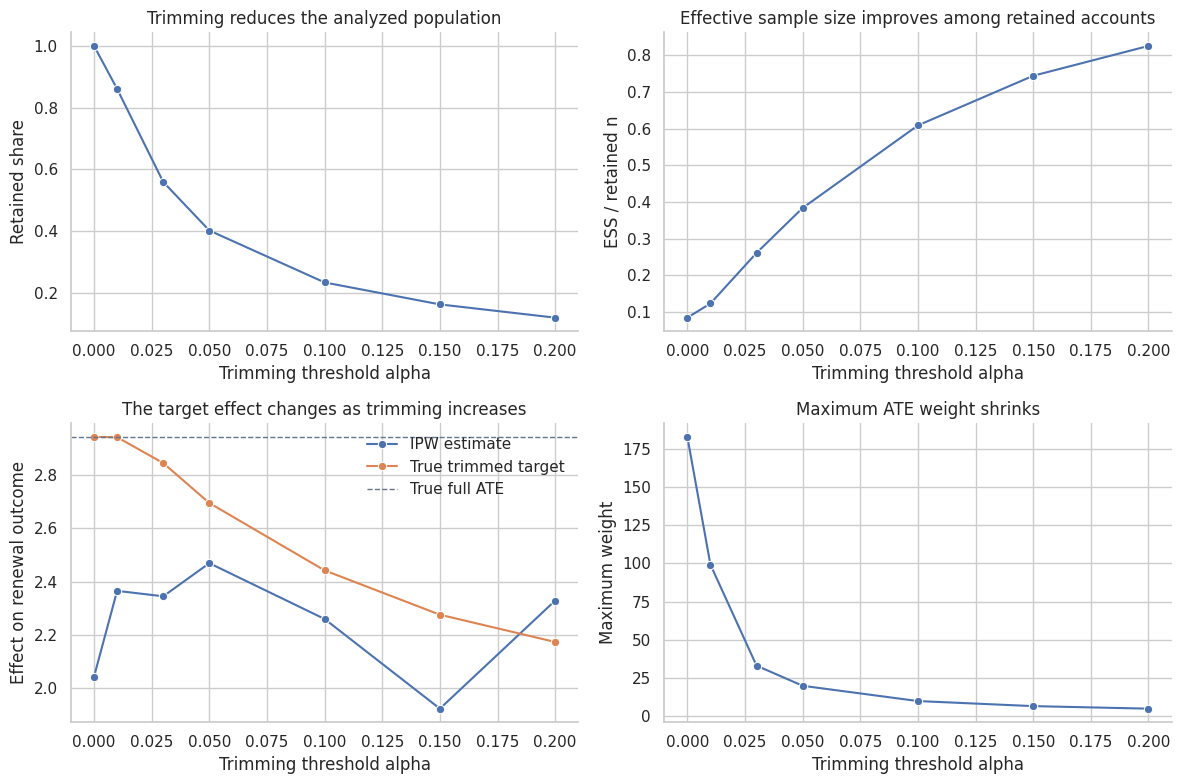

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.lineplot(data=trim_results, x="alpha", y="retained_share", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Trimming reduces the analyzed population")
axes[0, 0].set_ylabel("Retained share")

sns.lineplot(data=trim_results, x="alpha", y="ess_share_of_retained", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Effective sample size improves among retained accounts")
axes[0, 1].set_ylabel("ESS / retained n")

sns.lineplot(data=trim_results, x="alpha", y="estimate", marker="o", label="IPW estimate", ax=axes[1, 0])
sns.lineplot(data=trim_results, x="alpha", y="true_trimmed_effect", marker="o", label="True trimmed target", ax=axes[1, 0])
axes[1, 0].axhline(true_ate, color="#64748b", linestyle="--", linewidth=1, label="True full ATE")
axes[1, 0].set_title("The target effect changes as trimming increases")
axes[1, 0].set_ylabel("Effect on renewal outcome")
axes[1, 0].legend(frameon=False)

sns.lineplot(data=trim_results, x="alpha", y="max_weight", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Maximum ATE weight shrinks")
axes[1, 1].set_ylabel("Maximum weight")

for ax in axes.flat:
    ax.set_xlabel("Trimming threshold alpha")
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

Trimming stabilizes the design by removing accounts with very low or very high estimated treatment probabilities. As $\alpha$ increases, the maximum weight falls and the effective sample size among retained accounts improves.

But the true target effect also changes. In this simulation, the heavily trimmed population has a lower average treatment effect than the full population because it contains fewer high-value enterprise accounts and fewer very low-propensity accounts. That is the key lesson: trimming is not merely deleting inconvenient rows. It is redefining the population.

## 11. Who Gets Removed?

A trim rule should be translated back into business language. Stakeholders rarely think in propensity-score intervals. They think in customer segments, contract size, churn risk, product usage, geography, and policy rules.

Here we compare the full population with two trimmed analysis populations.

In [14]:
def population_profile(mask, label):
    frame = df.loc[mask]
    return {
        "population": label,
        "n": len(frame),
        "outreach_share": frame["treated"].mean(),
        "enterprise_share": (frame["segment"] == "enterprise").mean(),
        "mid_market_share": (frame["segment"] == "mid_market").mean(),
        "self_serve_share": (frame["segment"] == "self_serve").mean(),
        "mean_contract_value": frame["contract_value"].mean(),
        "mean_usage": frame["usage"].mean(),
        "mean_churn_risk": frame["churn_risk"].mean(),
        "mean_true_effect": frame["true_individual_effect"].mean(),
    }

profiles = pd.DataFrame([
    population_profile(np.ones(len(df), dtype=bool), "Full population"),
    population_profile(df["ps_hat"].between(0.03, 0.97), "Trim 0.03 to 0.97"),
    population_profile(df["ps_hat"].between(0.10, 0.90), "Trim 0.10 to 0.90"),
    population_profile(df["ps_hat"].between(0.20, 0.80), "Trim 0.20 to 0.80"),
])

display(profiles)

,population,n,outreach_share,enterprise_share,mid_market_share,self_serve_share,mean_contract_value,mean_usage,mean_churn_risk,mean_true_effect
0,Full population,9000,0.102,0.200,0.341,0.458,53.437,52.943,0.169,2.943
1,Trim 0.03 to 0.97,5030,0.168,0.274,0.361,0.365,58.856,45.939,0.246,2.845
2,Trim 0.10 to 0.90,2096,0.305,0.189,0.378,0.433,58.761,39.301,0.380,2.442
3,Trim 0.20 to 0.80,1068,0.427,0.115,0.407,0.478,54.795,36.680,0.469,2.174


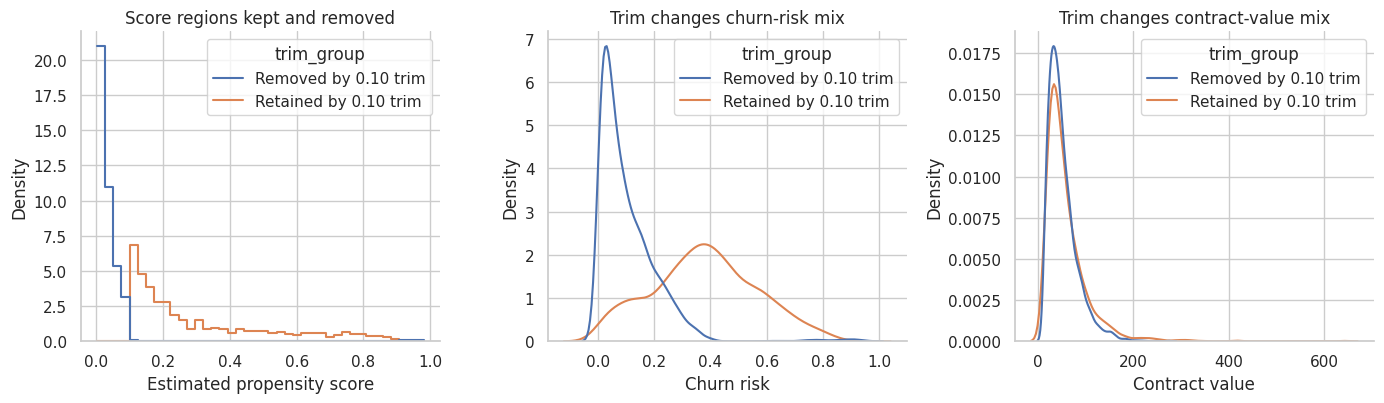

In [15]:
plot_profile = df.copy()
plot_profile["trim_group"] = "Removed by 0.10 trim"
plot_profile.loc[df["ps_hat"].between(0.10, 0.90), "trim_group"] = "Retained by 0.10 trim"

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.histplot(
    data=plot_profile,
    x="ps_hat",
    hue="trim_group",
    stat="density",
    common_norm=False,
    bins=40,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Score regions kept and removed")
axes[0].set_xlabel("Estimated propensity score")

sns.kdeplot(
    data=plot_profile,
    x="churn_risk",
    hue="trim_group",
    common_norm=False,
    fill=False,
    ax=axes[1],
)
axes[1].set_title("Trim changes churn-risk mix")
axes[1].set_xlabel("Churn risk")

sns.kdeplot(
    data=plot_profile,
    x="contract_value",
    hue="trim_group",
    common_norm=False,
    fill=False,
    ax=axes[2],
)
axes[2].set_title("Trim changes contract-value mix")
axes[2].set_xlabel("Contract value")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

The 0.10 trim does not remove a random subset of accounts. It removes many accounts in regions where the outreach decision was nearly predetermined. That changes the customer story.

A good business readout would not say: "After trimming, outreach increases renewal value by X." It would say: "Among accounts whose historical characteristics made either outreach decision reasonably plausible, outreach increases renewal value by X. This excludes accounts in the most deterministic targeting regions."

## 12. Overlap Weights as a Smooth Alternative

Trimming makes a hard decision: keep or drop. Overlap weights make a smooth decision: emphasize accounts near equipoise and downweight boundary accounts.

For a general balancing-weight target, define a target function $h(X)$. The group-specific weights are:

$$
w_i(1) = \frac{h(X_i)}{e(X_i)}, \quad w_i(0) = \frac{h(X_i)}{1 - e(X_i)}.
$$

For overlap weights, $h(X_i) = e(X_i)\{1-e(X_i)\}$, so:

$$
w_i^{OW} = D_i\{1 - \hat e(X_i)\} + (1-D_i)\hat e(X_i).
$$

The target density is highest when $\hat e(X_i)$ is near $0.5$ and lowest near the boundaries.

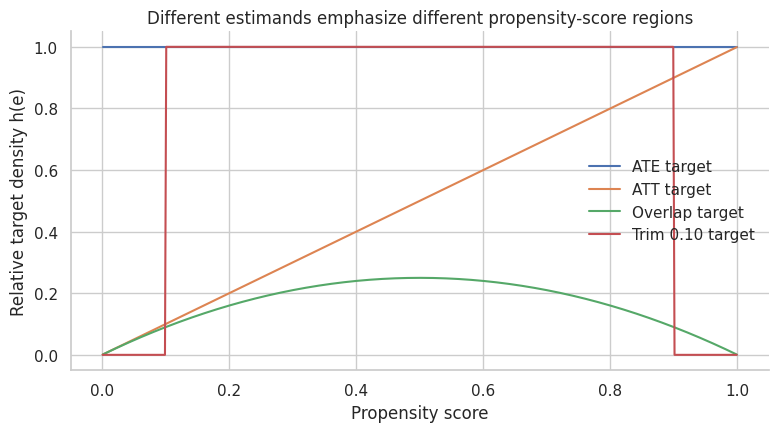

In [16]:
grid = np.linspace(0.001, 0.999, 500)
weight_functions = pd.DataFrame({
    "propensity_score": np.tile(grid, 4),
    "target": np.repeat(["ATE target", "ATT target", "Overlap target", "Trim 0.10 target"], len(grid)),
    "h_of_e": np.concatenate([
        np.ones_like(grid),
        grid,
        grid * (1 - grid),
        ((grid >= 0.10) & (grid <= 0.90)).astype(float),
    ]),
})

fig, ax = plt.subplots(figsize=(9, 4.4))
sns.lineplot(data=weight_functions, x="propensity_score", y="h_of_e", hue="target", ax=ax)
ax.set_title("Different estimands emphasize different propensity-score regions")
ax.set_xlabel("Propensity score")
ax.set_ylabel("Relative target density h(e)")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

### Interpretation

The ATE target weights all score regions equally in the target population. The ATT target emphasizes regions where treated units are common. The overlap target emphasizes the middle of the score distribution, where either treatment condition was plausible.

This is why overlap weights are attractive when the scientific or business question is about the "decision margin": accounts where the organization could reasonably have gone either way. They are less appropriate if leadership truly needs a full-population answer that includes regions where historical decisions were nearly deterministic.

## 13. Compare Full ATE, Trimming, and Overlap Weights

Now we combine point estimates, target effects, weight stability, and balance in one table.

In [17]:
def design_row(label, frame, weights, target_weights, balance_frame_subset):
    balance = standardized_mean_differences(balance_frame_subset, balance_covariates, weights=weights)
    return {
        "design": label,
        "n_used": len(frame),
        "estimate": weighted_difference(frame, weights=weights),
        "true_target_effect": true_weighted_effect(frame, target_weights=target_weights),
        "error_vs_target": weighted_difference(frame, weights=weights) - true_weighted_effect(frame, target_weights=target_weights),
        "ess": effective_sample_size(weights),
        "ess_share_of_n_used": effective_sample_size(weights) / len(frame),
        "max_weight": np.max(weights),
        "max_abs_smd": balance["abs_smd"].max(),
        "mean_abs_smd": balance["abs_smd"].mean(),
    }

mask_003 = df["ps_hat"].between(0.03, 0.97)
mask_010 = df["ps_hat"].between(0.10, 0.90)

comparison_rows = [
    design_row(
        "Full ATE IPW",
        df,
        df["ate_weight"].to_numpy(),
        np.ones(len(df)),
        balance_frame,
    ),
    design_row(
        "Trim 0.03 ATE IPW",
        df.loc[mask_003],
        ate_weights(df.loc[mask_003, "treated"], df.loc[mask_003, "ps_hat"]),
        np.ones(mask_003.sum()),
        balance_frame.loc[mask_003],
    ),
    design_row(
        "Trim 0.10 ATE IPW",
        df.loc[mask_010],
        ate_weights(df.loc[mask_010, "treated"], df.loc[mask_010, "ps_hat"]),
        np.ones(mask_010.sum()),
        balance_frame.loc[mask_010],
    ),
    design_row(
        "Overlap weights",
        df,
        df["overlap_weight"].to_numpy(),
        df["ps_hat"].to_numpy() * (1 - df["ps_hat"].to_numpy()),
        balance_frame,
    ),
    design_row(
        "ATT weights",
        df,
        df["att_weight"].to_numpy(),
        df["treated"].to_numpy(),
        balance_frame,
    ),
]

design_comparison = pd.DataFrame(comparison_rows)
display(design_comparison)

,design,n_used,estimate,true_target_effect,error_vs_target,ess,ess_share_of_n_used,max_weight,max_abs_smd,mean_abs_smd
0,Full ATE IPW,9000,2.044,2.943,-0.899,760.026,0.084,182.798,8.389e-02,2.396e-02
1,Trim 0.03 ATE IPW,5030,2.345,2.845,-0.500,1313.564,0.261,33.149,5.167e-02,2.025e-02
2,Trim 0.10 ATE IPW,2096,2.260,2.442,-0.182,1276.735,0.609,9.972,4.721e-02,2.731e-02
3,Overlap weights,9000,2.304,2.631,-0.327,2244.526,0.249,0.995,1.390e-14,4.249e-15
4,ATT weights,9000,1.696,2.341,-0.645,1595.149,0.177,13.512,9.653e-02,4.837e-02


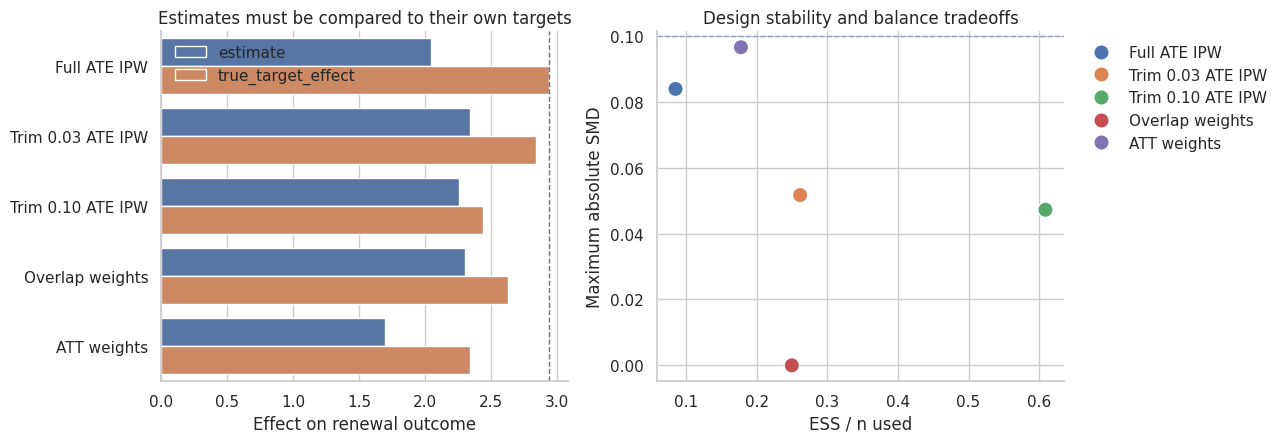

In [18]:
plot_df = design_comparison.melt(
    id_vars="design",
    value_vars=["estimate", "true_target_effect"],
    var_name="quantity",
    value_name="effect",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.barplot(data=plot_df, y="design", x="effect", hue="quantity", ax=axes[0])
axes[0].axvline(true_ate, color="#64748b", linestyle="--", linewidth=1)
axes[0].set_title("Estimates must be compared to their own targets")
axes[0].set_xlabel("Effect on renewal outcome")
axes[0].set_ylabel("")
axes[0].legend(frameon=False)

sns.scatterplot(
    data=design_comparison,
    x="ess_share_of_n_used",
    y="max_abs_smd",
    hue="design",
    s=120,
    ax=axes[1],
)
axes[1].axhline(0.10, color="#94a3b8", linestyle="--", linewidth=1)
axes[1].set_title("Design stability and balance tradeoffs")
axes[1].set_xlabel("ESS / n used")
axes[1].set_ylabel("Maximum absolute SMD")
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

There is no universal winner. The full ATE IPW design answers the broadest question, but it is vulnerable to weak overlap. The trimmed designs are more stable, but the target population narrows. The overlap-weighted design is stable and well-aligned with the region of empirical equipoise, but it no longer represents the full customer base.

In an industry project, this table is the beginning of a conversation with stakeholders. If they need a decision for all customers, the data may be insufficient and the recommendation might be to run an experiment or collect better support. If they need a decision for accounts near the operational margin, overlap weights may be exactly the right estimand.

## 14. Sensitivity to the Trimming Threshold

Because trimming is a design choice, we should show how sensitive the conclusion is to reasonable thresholds. A result that changes dramatically across $\alpha$ values deserves caution.

,alpha,retained_share,estimate,true_trimmed_effect,estimation_error_vs_trimmed_target,true_effect_shift_vs_full_ATE,ess_share_of_retained,max_abs_smd
0,0.00,1.000,2.044,2.943,-0.899,0.000,0.084,0.084
1,0.01,0.861,2.365,2.942,-0.576,-0.001,0.123,0.054
2,0.03,0.559,2.345,2.845,-0.500,-0.098,0.261,0.052
3,0.05,0.401,2.469,2.695,-0.226,-0.248,0.384,0.059
4,0.10,0.233,2.260,2.442,-0.182,-0.501,0.609,0.047
5,0.15,0.162,1.923,2.276,-0.353,-0.667,0.745,0.102
6,0.20,0.119,2.329,2.174,0.155,-0.769,0.826,0.105


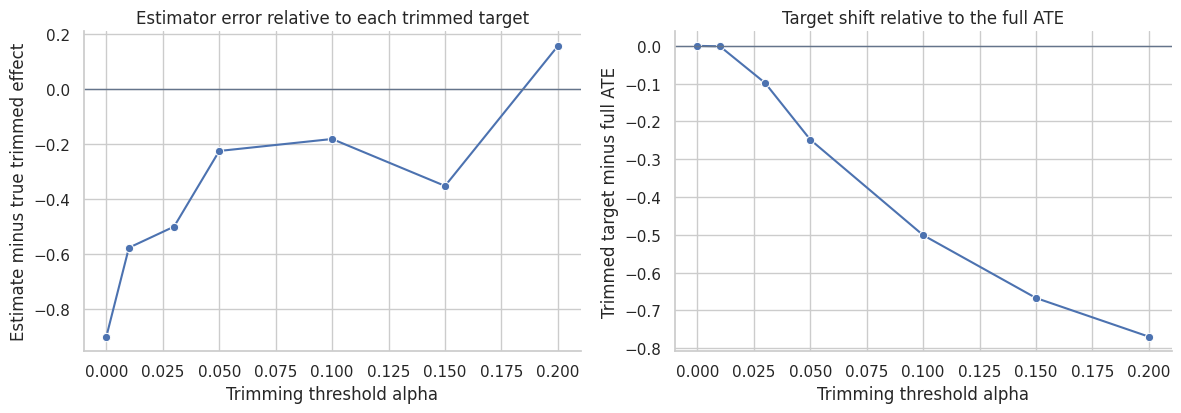

In [19]:
trim_sensitivity = trim_results[[
    "alpha",
    "retained_share",
    "estimate",
    "true_trimmed_effect",
    "estimation_error_vs_trimmed_target",
    "true_effect_shift_vs_full_ATE",
    "ess_share_of_retained",
    "max_abs_smd",
]].copy()

display(trim_sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

sns.lineplot(data=trim_sensitivity, x="alpha", y="estimation_error_vs_trimmed_target", marker="o", ax=axes[0])
axes[0].axhline(0, color="#64748b", linewidth=1)
axes[0].set_title("Estimator error relative to each trimmed target")
axes[0].set_xlabel("Trimming threshold alpha")
axes[0].set_ylabel("Estimate minus true trimmed effect")

sns.lineplot(data=trim_sensitivity, x="alpha", y="true_effect_shift_vs_full_ATE", marker="o", ax=axes[1])
axes[1].axhline(0, color="#64748b", linewidth=1)
axes[1].set_title("Target shift relative to the full ATE")
axes[1].set_xlabel("Trimming threshold alpha")
axes[1].set_ylabel("Trimmed target minus full ATE")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

This plot separates two sources of movement:

1. **Estimator error**: how far the estimator is from the target it claims to estimate.
2. **Target shift**: how much the target itself changes as the analysis population changes.

In real data we cannot observe the true target effects, but we can always report the retained population, covariate profiles, balance, and weight diagnostics. Those diagnostics help stakeholders understand whether different thresholds are telling a consistent story or whether the analysis is mostly driven by a fragile support decision.

## 15. Structural vs Practical Positivity in the Example

The strict targeting rule in our simulation is not perfectly deterministic, but it mimics a business rule that pushes a subgroup strongly toward outreach. We can inspect this subgroup directly.

,accounts,outreach_share,mean_ps,min_ps,max_ps,mean_contract_value,mean_churn_risk,mean_true_effect
strict_targeting_rule,,,,,,,,
Rule not triggered,9000,0.102,0.102,0.001,0.98,53.437,0.169,2.943


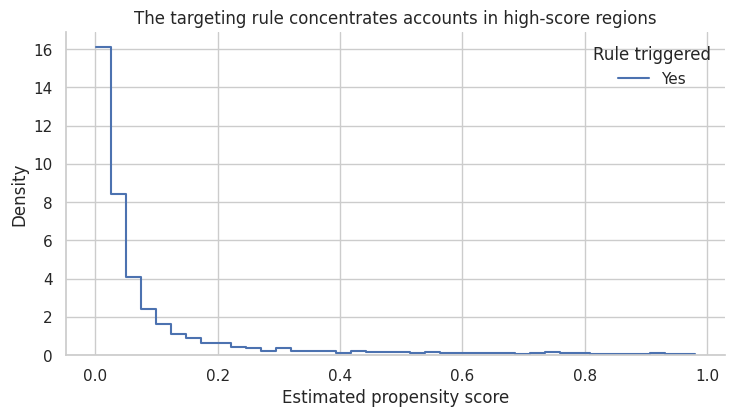

In [20]:
rule_table = (
    df.groupby("strict_targeting_rule")
    .agg(
        accounts=("treated", "size"),
        outreach_share=("treated", "mean"),
        mean_ps=("ps_hat", "mean"),
        min_ps=("ps_hat", "min"),
        max_ps=("ps_hat", "max"),
        mean_contract_value=("contract_value", "mean"),
        mean_churn_risk=("churn_risk", "mean"),
        mean_true_effect=("true_individual_effect", "mean"),
    )
    .rename(index={0.0: "Rule not triggered", 1.0: "Rule triggered"})
)

display(rule_table)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
sns.histplot(
    data=df,
    x="ps_hat",
    hue="strict_targeting_rule",
    stat="density",
    common_norm=False,
    bins=40,
    element="step",
    fill=False,
    ax=ax,
)
ax.set_title("The targeting rule concentrates accounts in high-score regions")
ax.set_xlabel("Estimated propensity score")
ax.legend(title="Rule triggered", labels=["Yes", "No"], frameon=False)
sns.despine(ax=ax)
plt.show()

### Interpretation

When a policy rule strongly determines treatment, we should not hide it inside a generic propensity model. We should name it.

A structural positivity issue often calls for a change in the research question. For example, if enterprise high-risk accounts are always contacted, historical data may not support the effect of withholding outreach from those accounts. The right next step might be a carefully governed experiment, a phased rollout, or a different target estimand.

A practical positivity issue may be less severe. If there are some untreated examples but not many, trimming, overlap weights, matching with calipers, or collecting more data may be reasonable responses.

## 16. A Practical Decision Workflow

An overlap workflow for observational industry projects can be written as a design checklist.

1. **State the original target**: full customers, treated customers, eligible customers, or decision-margin customers.
2. **Estimate treatment propensities** using pre-treatment covariates and known assignment rules.
3. **Inspect score overlap** with distributions, score-bin tables, and local treated/control counts.
4. **Inspect weights** for ESS, maximum weight, high percentiles, and concentration.
5. **Inspect balance** after applying the candidate design.
6. **Translate exclusions** into business terms if trimming or matching removes units.
7. **Rename the estimand** whenever the design changes the target population.
8. **Escalate to better data collection** when the desired target is not supported.

In [21]:
def design_recommendation(row):
    if row["max_abs_smd"] > 0.10:
        return "Revise design: balance remains weak"
    if row["ess_share_of_n_used"] < 0.25:
        return "Caution: estimate depends on limited effective information"
    if "Trim" in row["design"]:
        return "Usable if stakeholders accept the trimmed target"
    if row["design"] == "Overlap weights":
        return "Usable for decision-margin target"
    if row["design"] == "ATT weights":
        return "Usable for treated-population target"
    return "Usable only if full-population support is defensible"

readiness = design_comparison.copy()
readiness["recommendation"] = readiness.apply(design_recommendation, axis=1)
readiness = readiness[[
    "design",
    "n_used",
    "estimate",
    "true_target_effect",
    "ess_share_of_n_used",
    "max_weight",
    "max_abs_smd",
    "recommendation",
]]

display(readiness)

,design,n_used,estimate,true_target_effect,ess_share_of_n_used,max_weight,max_abs_smd,recommendation
0,Full ATE IPW,9000,2.044,2.943,0.084,182.798,8.389e-02,Caution: estimate depends on limited effective...
1,Trim 0.03 ATE IPW,5030,2.345,2.845,0.261,33.149,5.167e-02,Usable if stakeholders accept the trimmed target
2,Trim 0.10 ATE IPW,2096,2.260,2.442,0.609,9.972,4.721e-02,Usable if stakeholders accept the trimmed target
3,Overlap weights,9000,2.304,2.631,0.249,0.995,1.390e-14,Caution: estimate depends on limited effective...
4,ATT weights,9000,1.696,2.341,0.177,13.512,9.653e-02,Caution: estimate depends on limited effective...


### Interpretation

The recommendation column is intentionally conservative. In real work, the numerical cutoffs should be adapted to sample size, domain risk, and the cost of acting on a wrong estimate. The deeper principle is stable: do not let a clean-looking estimate outrun the support in the data.

## 17. Reporting Template

A concise overlap report might look like this:

> We estimated the probability of outreach using pre-treatment account characteristics and known targeting rules. The fitted scores showed weak full-population overlap: many accounts had very low outreach probability, and high-risk enterprise accounts had high outreach probability. Full ATE IPW produced large weights and low effective sample size. We therefore report the overlap-weighted effect as the primary observational estimate, targeting accounts whose historical characteristics made either outreach decision plausible. We also show trimmed ATE sensitivity analyses at thresholds $\alpha \in \{0.03, 0.05, 0.10\}$. These estimates should not be interpreted as effects for all accounts, especially accounts in deterministic targeting regions. A full-population answer would require stronger design support, ideally from randomization or deliberate exploration.

That paragraph does three professional things:

1. It names the diagnostic evidence.
2. It names the target population.
3. It prevents readers from overgeneralizing beyond the supported data.

## Key Takeaways

- Positivity means each treatment condition has positive probability for the covariate profiles in the target population.
- Weak overlap is not fixed by a more flexible outcome model. A flexible model can extrapolate, but it cannot create observed comparisons.
- Extreme IPW weights are often a symptom of weak overlap.
- Trimming can stabilize estimation, but it changes the target population and must be reported as such.
- Overlap weights target the population near empirical equipoise; this can be a highly relevant business estimand for decision-margin policies.
- In high-stakes industry decisions, an honest "the desired target is not supported by these observational data" is often better than an overconfident adjusted estimate.

## References

Crump, R. K., Hotz, V. J., Imbens, G. W., & Mitnik, O. A. (2009). Dealing with limited overlap in estimation of average treatment effects. *Biometrika, 96*(1), 187-199. https://doi.org/10.1093/biomet/asn055

Li, F., Morgan, K. L., & Zaslavsky, A. M. (2017). Balancing covariates via propensity score weighting. *Journal of the American Statistical Association, 113*(521), 390-400. https://doi.org/10.1080/01621459.2016.1260466

Petersen, M. L., Porter, K. E., Gruber, S., Wang, Y., & van der Laan, M. J. (2010). Diagnosing and responding to violations in the positivity assumption. *Statistical Methods in Medical Research, 21*(1), 31-54. https://doi.org/10.1177/0962280210386207

Westreich, D., & Cole, S. R. (2010). Invited commentary: Positivity in practice. *American Journal of Epidemiology, 171*(6), 674-677. https://doi.org/10.1093/aje/kwp436

Yang, S., & Ding, P. (2018). Asymptotic inference of causal effects with observational studies trimmed by the estimated propensity scores. *Biometrika, 105*(2), 487-493. https://doi.org/10.1093/biomet/asy008